# ML + LLM Fraud Detection Demo (Synthetic Data)

This notebook demonstrates the most common production pattern in fintech fraud detection:

1. A **machine learning model** scores structured transaction data.
2. An **LLM-style investigation layer** turns the alert into a human-readable explanation and case summary.

The notebook is fully self-contained and uses **synthetic data**, so it can run without access to private banking or payments data.

## What you will see

- How to generate a realistic fraud dataset with class imbalance.
- How to train a gradient-boosted fraud classifier.
- How to evaluate the model with standard fraud metrics.
- How to explain a flagged transaction with SHAP.
- How an LLM is used to turn model output into an analyst-friendly narrative.

The LLM part is implemented as a **mock assistant** so the notebook works offline. In a real deployment, that cell is where you would call GPT or another LLM API.

In [ ]:
# If needed, uncomment the next line in a fresh environment:
#!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
import shap

plt.style.use('default')
np.random.seed(42)


## 1) Create synthetic fraud data

We simulate the kinds of features commonly used in fintech fraud models:

- transaction amount
- customer account age
- whether the device is new
- failed login count
- transaction velocity
- merchant risk
- country risk
- time-of-day behavior
- a few behavioral ratios

The fraud label is generated from a hidden rule with some randomness, so the dataset behaves like a real imbalanced fraud problem.

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

n = 4000

amount = np.random.lognormal(mean=3.4, sigma=1.0, size=n)
amount = np.clip(amount, 1, 5000)
account_age_days = np.random.exponential(scale=900, size=n).astype(int)
account_age_days = np.clip(account_age_days, 1, 5000)
customer_avg_amount = np.random.lognormal(mean=3.1, sigma=0.7, size=n)
customer_avg_amount = np.clip(customer_avg_amount, 1, 2000)

amount_to_avg = amount / (customer_avg_amount + 1e-6)
new_device = np.random.binomial(1, 0.18, size=n)
failed_logins_24h = np.random.poisson(lam=0.7, size=n)
velocity_1h = np.random.poisson(lam=1.2, size=n)
merchant_risk = np.random.choice([0, 1, 2, 3], size=n, p=[0.45, 0.30, 0.18, 0.07])
country_risk = np.random.choice([0, 1, 2], size=n, p=[0.72, 0.20, 0.08])
hour = np.random.randint(0, 24, size=n)
night_txn = ((hour >= 0) & (hour <= 5)).astype(int)

# Hidden fraud logic: large unusual amounts, new device, high velocity, risky geographies,
# failed logins, and high-risk merchants all increase fraud probability.
logit = (
    -4.2
    + 0.9 * new_device
    + 0.55 * failed_logins_24h
    + 0.48 * velocity_1h
    + 0.65 * merchant_risk
    + 0.75 * country_risk
    + 0.35 * night_txn
    + 0.95 * np.log1p(amount_to_avg)
    - 0.00035 * account_age_days
)

fraud_prob = sigmoid(logit)
fraud = np.random.binomial(1, fraud_prob)

# Add a text field to show where an LLM could help interpret notes/chats.
notes = np.where(
    fraud == 1,
    np.random.choice([
        'Customer reported unexpected international transfer',
        'User mentioned losing access to their phone',
        'KYC documents had mismatched address details',
        'Multiple failed login attempts before card payment'
    ], size=n),
    np.random.choice([
        'Normal purchase at familiar merchant',
        'Regular salary deposit',
        'Low-risk domestic card payment',
        'Repeat transaction to known beneficiary'
    ], size=n)
)

df = pd.DataFrame({
    'amount': amount.round(2),
    'account_age_days': account_age_days,
    'customer_avg_amount': customer_avg_amount.round(2),
    'amount_to_avg': amount_to_avg.round(2),
    'new_device': new_device,
    'failed_logins_24h': failed_logins_24h,
    'velocity_1h': velocity_1h,
    'merchant_risk': merchant_risk,
    'country_risk': country_risk,
    'hour': hour,
    'night_txn': night_txn,
    'notes': notes,
    'fraud': fraud
})

df.head()


,amount,account_age_days,customer_avg_amount,amount_to_avg,new_device,failed_logins_24h,velocity_1h,merchant_risk,country_risk,hour,night_txn,notes,fraud
0,49.24,597,33.54,1.47,0,2,0,2,0,14,0,Regular salary deposit,0
1,26.09,80,3.47,7.52,0,1,0,0,0,8,0,Normal purchase at familiar merchant,0
2,57.26,3232,57.77,0.99,0,0,0,0,1,2,1,Normal purchase at familiar merchant,0
3,137.42,656,13.24,10.38,0,0,1,1,0,4,1,Normal purchase at familiar merchant,0
4,23.71,857,35.89,0.66,0,1,2,0,0,9,0,Normal purchase at familiar merchant,0


In [ ]:
print('Rows:', len(df))
print('Fraud rate:', round(df['fraud'].mean() * 100, 2), '%')
print('Feature snapshot:')
print(df.drop(columns=['notes']).describe().T[['mean', 'std', 'min', 'max']].round(2))


Rows: 4000
Fraud rate: 25.17 %
Feature snapshot:
                       mean     std   min      max
amount                50.52   69.40  1.17  1519.65
account_age_days     865.29  858.54  1.00  5000.00
customer_avg_amount   28.12   21.69  1.43   236.08
amount_to_avg          2.85    4.86  0.03    81.43
new_device             0.18    0.38  0.00     1.00
failed_logins_24h      0.73    0.87  0.00     5.00
velocity_1h            1.19    1.08  0.00     7.00
merchant_risk          0.86    0.93  0.00     3.00
country_risk           0.36    0.63  0.00     2.00
hour                  11.47    7.04  0.00    23.00
night_txn              0.26    0.44  0.00     1.00
fraud                  0.25    0.43  0.00     1.00


## 2) Train a fraud model

A gradient-boosted tree model is a very common choice for tabular fraud detection because it handles nonlinear patterns and mixed feature types well.

We use **XGBoost** here, which is one of the most common families of models in production fraud systems.

In [ ]:
feature_cols = [
    'amount', 'account_age_days', 'customer_avg_amount', 'amount_to_avg',
    'new_device', 'failed_logins_24h', 'velocity_1h', 'merchant_risk',
    'country_risk', 'hour', 'night_txn'
]

X = df[feature_cols]
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Handle imbalance with sample weights.
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

model = XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    n_jobs=4
)

model.fit(X_train, y_train, sample_weight=sample_weight)

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

print('ROC AUC:', round(roc_auc_score(y_test, probs), 4))
print('Average Precision:', round(average_precision_score(y_test, probs), 4))
print('Classification report at threshold=0.5')
print(classification_report(y_test, preds, digits=4))


ROC AUC: 0.7905
Average Precision: 0.5959
Classification report at threshold=0.5
              precision    recall  f1-score   support

           0     0.8786    0.7834    0.8283       748
           1     0.5135    0.6786    0.5846       252

    accuracy                         0.7570      1000
   macro avg     0.6960    0.7310    0.7064      1000
weighted avg     0.7866    0.7570    0.7669      1000



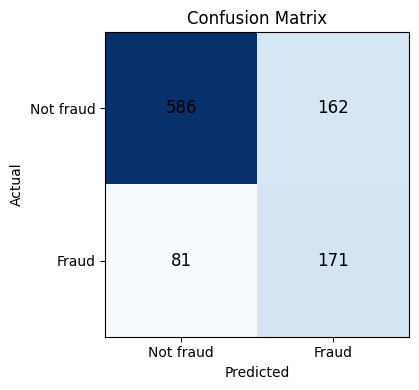

In [ ]:
cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not fraud', 'Fraud'])
ax.set_yticklabels(['Not fraud', 'Fraud'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()


## 3) Explain a single alert with SHAP

In fraud operations, the model score alone is not enough. Analysts also need to know **why** a transaction was flagged.

SHAP gives a local explanation by showing which features pushed the prediction up or down.

In [ ]:
# Pick one example with a high predicted risk
alert_idx = np.argsort(probs)[-1]
alert = X_test.iloc[[alert_idx]].copy()
alert_prob = probs[alert_idx]
alert_actual = y_test.iloc[alert_idx]

print('Predicted fraud probability:', round(float(alert_prob), 4))
print('Actual label:', int(alert_actual))
alert


Predicted fraud probability: 0.9636
Actual label: 1


,amount,account_age_days,customer_avg_amount,amount_to_avg,new_device,failed_logins_24h,velocity_1h,merchant_risk,country_risk,hour,night_txn
3582,204.46,417,4.46,45.8,1,0,2,2,0,19,0


Top SHAP drivers:
            feature  value  shap_value
      amount_to_avg  45.80    1.826035
         new_device   1.00    0.521020
      merchant_risk   2.00    0.471397
customer_avg_amount   4.46    0.320576
  failed_logins_24h   0.00   -0.310353


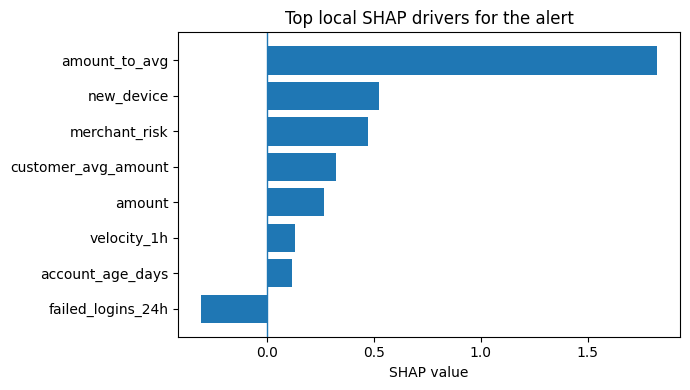

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(alert)

# Compatibility across SHAP versions
if isinstance(shap_values, list):
    sv = shap_values[1][0]
    expected_value = explainer.expected_value[1]
else:
    sv = shap_values[0]
    expected_value = explainer.expected_value

shap_df = pd.DataFrame({
    'feature': alert.columns,
    'value': alert.iloc[0].values,
    'shap_value': sv
}).sort_values('shap_value', key=np.abs, ascending=False)

print('Top SHAP drivers:')
print(shap_df.head(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
show_df = shap_df.head(8).sort_values('shap_value')
ax.barh(show_df['feature'], show_df['shap_value'])
ax.set_title('Top local SHAP drivers for the alert')
ax.set_xlabel('SHAP value')
ax.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()


## 4) Build the LLM prompt

This is the part that usually gets added in a real fintech workflow.

The LLM receives:
- the transaction summary
- the model score
- the most important explanation features
- relevant note text or customer comments

Its job is to translate the alert into a concise human narrative for an analyst.

In [ ]:
def build_llm_prompt(transaction_row, fraud_probability, top_drivers, note_text):
    driver_lines = []
    for _, row in top_drivers.iterrows():
        direction = 'increased' if row['shap_value'] > 0 else 'decreased'
        driver_lines.append(f"- {row['feature']}: {row['value']} ({direction} risk)")

    prompt = f'''
You are a senior fraud analyst assisting with a fintech alert.

Transaction summary:
- Predicted fraud probability: {fraud_probability:.3f}
- Amount: {transaction_row['amount']:.2f}
- Account age (days): {int(transaction_row['account_age_days'])}
- New device: {int(transaction_row['new_device'])}
- Failed logins (24h): {int(transaction_row['failed_logins_24h'])}
- Velocity (1h): {int(transaction_row['velocity_1h'])}
- Merchant risk: {int(transaction_row['merchant_risk'])}
- Country risk: {int(transaction_row['country_risk'])}
- Night transaction: {int(transaction_row['night_txn'])}
- Analyst note: {note_text}

Top model drivers:
{chr(10).join(driver_lines)}

Write:
1. A one-paragraph explanation of why the alert is suspicious.
2. A short analyst recommendation.
3. Keep the tone concise and professional.
'''
    return prompt

prompt = build_llm_prompt(alert.iloc[0], float(alert_prob), shap_df.head(5), df.loc[alert.index[0], 'notes'])
print(prompt)



You are a senior fraud analyst assisting with a fintech alert.

Transaction summary:
- Predicted fraud probability: 0.964
- Amount: 204.46
- Account age (days): 417
- New device: 1
- Failed logins (24h): 0
- Velocity (1h): 2
- Merchant risk: 2
- Country risk: 0
- Night transaction: 0
- Analyst note: KYC documents had mismatched address details

Top model drivers:
- amount_to_avg: 45.8 (increased risk)
- new_device: 1.0 (increased risk)
- merchant_risk: 2.0 (increased risk)
- customer_avg_amount: 4.46 (increased risk)
- failed_logins_24h: 0.0 (decreased risk)

Write:
1. A one-paragraph explanation of why the alert is suspicious.
2. A short analyst recommendation.
3. Keep the tone concise and professional.



## 5) Mock the LLM output

The notebook uses a lightweight deterministic function so the example works offline.

In production, this cell would be replaced by an API call to your chosen LLM.

In [ ]:
def mock_llm_response(transaction_row, fraud_probability, top_drivers, note_text):
    strong_positive = top_drivers[top_drivers['shap_value'] > 0].head(3)
    reasons = []
    for _, row in strong_positive.iterrows():
        if row['feature'] == 'new_device':
            reasons.append('the payment came from a new device')
        elif row['feature'] == 'failed_logins_24h':
            reasons.append('there were multiple failed login attempts')
        elif row['feature'] == 'velocity_1h':
            reasons.append('transaction velocity was unusually high')
        elif row['feature'] == 'amount_to_avg':
            reasons.append("the amount was much larger than the customer's normal behavior")
        elif row['feature'] == 'country_risk':
            reasons.append('the transaction involved a risky country')
        elif row['feature'] == 'merchant_risk':
            reasons.append('the merchant had elevated risk')
        elif row['feature'] == 'night_txn':
            reasons.append('the transaction occurred at an unusual hour')

    reason_text = ', '.join(reasons[:3]) if reasons else 'the model found an unusual combination of behavior signals'

    return (
        f"This transaction is high risk because {reason_text}. "
        f"The model score is {fraud_probability:.1%}, and the note '{note_text}' is consistent with prior fraud cases. "
        f"Recommended action: hold for manual review, verify customer identity, and check recent account activity before release."
    )

summary = mock_llm_response(alert.iloc[0], float(alert_prob), shap_df.head(5), df.loc[alert.index[0], 'notes'])
print(summary)


This transaction is high risk because the amount was much larger than the customer's normal behavior, the payment came from a new device, the merchant had elevated risk. The model score is 96.4%, and the note 'KYC documents had mismatched address details' is consistent with prior fraud cases. Recommended action: hold for manual review, verify customer identity, and check recent account activity before release.


In [ ]:
!pip install -q transformers accelerate sentencepiece

In [ ]:
from transformers import pipeline

llm = pipeline(
    "text-generation",
    model="microsoft/Phi-3-mini-4k-instruct",
    device_map="auto"
)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

In [ ]:
def generate_llm_summary(
    transaction_row,
    fraud_probability,
    top_drivers,
    note_text
):

    shap_explanation = []

    for _, row in top_drivers.iterrows():
        shap_explanation.append(
            f"{row['feature']} (SHAP={row['shap_value']:.3f})"
        )

    transaction_data = transaction_row.to_dict()

    prompt = f"""
You are a senior fraud analyst.

Fraud probability:
{fraud_probability:.2%}

Transaction:
{transaction_data}

Top SHAP drivers:
{', '.join(shap_explanation)}

Customer note:
{note_text}

Write a professional fraud investigation summary.

Include:
1. Why the transaction was flagged.
2. The most important SHAP drivers.
3. Recommended next actions.

Keep the report under 200 words.
"""

    response = llm(
        prompt,
        max_new_tokens=250,
        do_sample=False
    )

    return response[0]["generated_text"]

In [ ]:
summary = generate_llm_summary(
    alert.iloc[0],                         # transaction
    float(alert_prob),                     # fraud probability
    shap_df.head(5),                       # top SHAP features
    df.loc[alert.index[0], "notes"]        # customer note
)

print("\n" + "="*80)
print("LLM FRAUD INVESTIGATION REPORT")
print("="*80)
print(summary)

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



LLM FRAUD INVESTIGATION REPORT

You are a senior fraud analyst.

Fraud probability:
96.36%

Transaction:
{'amount': 204.46, 'account_age_days': 417.0, 'customer_avg_amount': 4.46, 'amount_to_avg': 45.8, 'new_device': 1.0, 'failed_logins_24h': 0.0, 'velocity_1h': 2.0, 'merchant_risk': 2.0, 'country_risk': 0.0, 'hour': 19.0, 'night_txn': 0.0}

Top SHAP drivers:
amount_to_avg (SHAP=1.826), new_device (SHAP=0.521), merchant_risk (SHAP=0.471), customer_avg_amount (SHAP=0.321), failed_logins_24h (SHAP=-0.310)

Customer note:
KYC documents had mismatched address details

Write a professional fraud investigation summary.

Include:
1. Why the transaction was flagged.
2. The most important SHAP drivers.
3. Recommended next actions.

Keep the report under 200 words.


## Solution:

Fraud Investigation Summary:

The transaction in question was flagged due to a high probability of fraud, standing at 96.36%. The primary factors contributing to this assessment include a significant deviation from th

## 6) End-to-end workflow

This is the key pattern to remember:

1. **ML model** produces a fraud score.
2. **Explainability layer** identifies the main drivers.
3. **LLM layer** turns those drivers into a readable analyst summary.
4. **Human investigator** decides the final action.

That is the most common real-world use case for LLMs in fraud detection today.

In [ ]:
result = pd.DataFrame({
    'predicted_fraud_probability': [float(alert_prob)],
    'actual_label': [int(alert_actual)],
    'top_drivers': [', '.join(shap_df.head(3)['feature'].tolist())],
    'llm_summary': [summary]
})
result


,predicted_fraud_probability,actual_label,top_drivers,llm_summary
0,0.963587,1,"amount_to_avg, new_device, merchant_risk",\nYou are a senior fraud analyst.\n\nFraud pro...


**SHAP** stands for **SHapley Additive exPlanations**.

It is one of the most widely used techniques for explaining **why a machine learning model made a specific prediction**, especially for models like:

* XGBoost
* LightGBM
* Random Forest
* Neural Networks

It is heavily used in:

* Fraud Detection
* Credit Scoring
* AML
* Risk Management
* Regulatory reporting

---

## The intuition

Suppose your fraud model says:

> Transaction Fraud Probability = 92%

The fraud analyst's next question is:

> "Why?"

SHAP decomposes the prediction into feature contributions.

Instead of just:

```text
Fraud Probability = 92%
```

You get:

| Feature                | Contribution |
| ---------------------- | ------------ |
| New device             | +25%         |
| High amount            | +20%         |
| Foreign country        | +15%         |
| Night-time transaction | +10%         |
| Trusted merchant       | -5%          |
| Long customer history  | -8%          |

Result:

```text
Base Risk      = 35%
+ New Device   = 25%
+ High Amount  = 20%
+ Foreign IP   = 15%
+ Night Time   = 10%
- Trusted Merch= -5%
- Customer Hist= -8%
---------------------
Final Risk     = 92%
```

This is exactly what fraud investigators want to see.

---

## Why it's called "Shapley"

SHAP comes from **Shapley Values**, a concept from game theory.

Imagine a football team wins a match.

Who deserves credit?

* Goal scorer?
* Midfielder?
* Goalkeeper?

Shapley values calculate each player's contribution to the victory.

In ML:

* Features = players
* Prediction = victory

SHAP estimates:

> How much did each feature contribute to the prediction?

---

## Example in Fraud Detection

Suppose a transaction looks like:

```text
Amount: €5,000
Country: Nigeria
Device: New Device
Previous Transactions Today: 12
```

Model predicts:

```text
Fraud = 96%
```

SHAP may output:

| Feature               | SHAP Value |
| --------------------- | ---------- |
| New Device            | +0.32      |
| Amount                | +0.25      |
| Country Risk          | +0.18      |
| Transaction Frequency | +0.12      |
| Account Age           | -0.05      |

Interpretation:

> The strongest reason this transaction was flagged is the new device, followed by the unusually large amount.

---

## Why Fraud Teams Love SHAP

Without SHAP:

```text
Fraud Score = 0.96
```

Analyst:

> "Okay... but why?"

---

With SHAP:

```text
Fraud Score = 0.96

Top Reasons:
1. New Device
2. Large Amount
3. High-Risk Country
4. Unusual Transaction Frequency
```

Now the analyst can investigate.

---

## How SHAP and LLMs Work Together

This is where the modern architecture becomes interesting.

### Step 1: ML Model

XGBoost predicts:

```text
Fraud Probability = 96%
```

### Step 2: SHAP

SHAP explains:

```text
New Device      +32%
Large Amount    +25%
High-Risk Country +18%
```

### Step 3: LLM

The LLM receives:

```json
{
  "fraud_probability": 0.96,
  "top_features": [
    {"feature":"New Device","impact":0.32},
    {"feature":"Large Amount","impact":0.25},
    {"feature":"High-Risk Country","impact":0.18}
  ]
}
```

And generates:

> "This transaction appears highly suspicious because it was initiated from a previously unseen device, involves an unusually large amount relative to the customer's historical behavior, and originates from a jurisdiction associated with elevated fraud risk."

This combination is becoming standard:

```text
XGBoost
    ↓
SHAP
    ↓
LLM Explanation
```

---

## Why I Included SHAP in the Notebook

Because it demonstrates the exact value of the **ML + LLM architecture**:

* **ML model** detects fraud.
* **SHAP** explains the model mathematically.
* **LLM** converts the explanation into analyst-friendly language.

That mirrors how many banks, payment processors, and AML systems operate today.


> "SHAP acts as the bridge between predictive machine learning models and LLM-based investigation systems, translating complex model outputs into feature-level explanations that LLMs can use to generate understandable fraud narratives for analysts and regulators. **Providing further material for the LLM to work on**."
